<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/music_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Music Genre Classification using Audio Features from the GTZAN Dataset


Dataset: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv('/content/features_3_sec.csv')


In [ ]:

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                

In [ ]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")

print(df.head())
print("\nColumn names:")


print(df.columns)


print("\nGenre distribution:")
print(df["label"].value_counts())


Shape of dataset: (9990, 60)

First 5 rows:
            filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3  blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4  blues.00000.4.wav   66149          0.335579         0.088129  0.143289   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   
3  0.002448             1655.289045          111952.284517   
4  0.001701             1630.656199           79667.267654   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.77156

In [ ]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Drop filename because it is not a useful predictive feature
if "filename" in df.columns:
    df.drop("filename", axis=1, inplace=True)

print("\nShape after dropping unnecessary columns:", df.shape)



Shape after dropping unnecessary columns: (9990, 59)


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)



Feature matrix shape: (9990, 58)
Target shape: (9990,)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes:")
for i, genre in enumerate(label_encoder.classes_):
    print(i, "->", genre)


Encoded classes:
0 -> blues
1 -> classical
2 -> country
3 -> disco
4 -> hiphop
5 -> jazz
6 -> metal
7 -> pop
8 -> reggae
9 -> rock


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)



Training set shape: (7992, 58)
Testing set shape: (1998, 58)


In [ ]:
df = df.dropna()

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale"))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),  # not required for RF, but okay for uniformity
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}

In [ ]:
results = {}

for name, pipeline in models.items():
    print("\n" + "="*60)
    print(f"Training: {name}")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": pipeline,
        "accuracy": acc,
        "predictions": y_pred
    }

    print(f"Accuracy: {acc:.4f}")


Training: Logistic Regression
Accuracy: 0.7197

Training: SVM
Accuracy: 0.9134

Training: Random Forest
Accuracy: 0.8714



Model Comparison:
                 Model  Accuracy
1                  SVM  0.913413
2        Random Forest  0.871371
0  Logistic Regression  0.719720


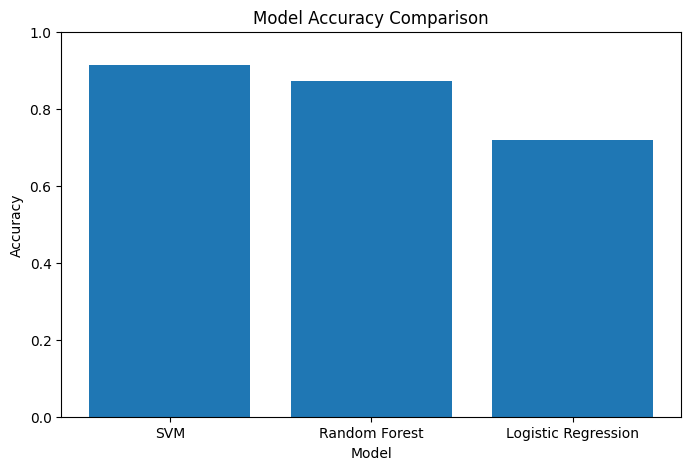

In [ ]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results]
}).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
best_y_pred = results[best_model_name]["predictions"]

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]['accuracy']:.4f}")
print("Best Model",best_model_name)



Best Model: SVM
Best Accuracy: 0.9134
Best Model SVM


Support Vector Matrix gives us the best result when compared with methods like Random Forest and Logistic Regression

In [ ]:
print("Classification Report:")
print(classification_report(
    y_test,
    best_y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
              precision    recall  f1-score   support

       blues       0.90      0.94      0.92       200
   classical       0.92      0.98      0.95       199
     country       0.87      0.86      0.87       199
       disco       0.88      0.88      0.88       200
      hiphop       0.93      0.91      0.92       200
        jazz       0.92      0.94      0.93       200
       metal       0.98      0.95      0.97       200
         pop       0.94      0.86      0.90       200
      reggae       0.90      0.92      0.91       200
        rock       0.90      0.90      0.90       200

    accuracy                           0.91      1998
   macro avg       0.91      0.91      0.91      1998
weighted avg       0.91      0.91      0.91      1998



<Figure size 1000x800 with 0 Axes>

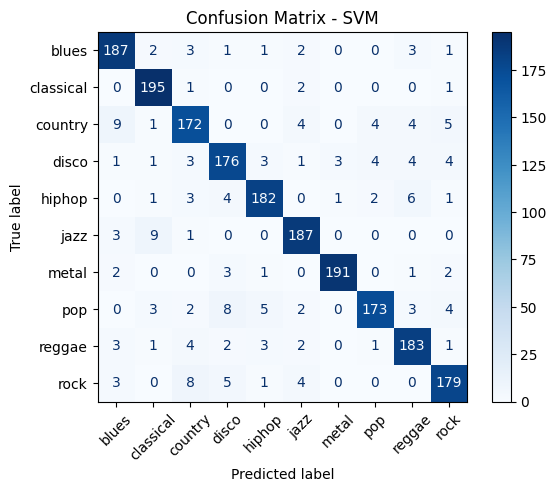

In [ ]:
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


In [ ]:
sample_index = 0
sample_features = X_test.iloc[[sample_index]]

predicted_class = best_model.predict(sample_features)[0]
actual_class = y_test[sample_index]

print("\nExample Prediction:")
print("Predicted genre:", label_encoder.inverse_transform([predicted_class])[0])
print("Actual genre   :", label_encoder.inverse_transform([actual_class])[0])


Example Prediction:
Predicted genre: country
Actual genre   : country


The best performing model was SVM with an accuracy of 0.9134.
This project demonstrates multi-class classification on audio-derived features from the GTZAN dataset.
The model can classify songs into music genres based on extracted acoustic characteristics.